DE RESULTS — Robot Basketball Shot Optimizer
Selected Population Size      : 8
Selected Generations          : 30

Best Speed v                  : 9.927276
Best Angle θ                  : 51.477325

Ball Height at Hoop y(D)      : 3.037615
Ball Height at Defender y(xd) : 4.171707

Final Objective Value J       : 0.197255


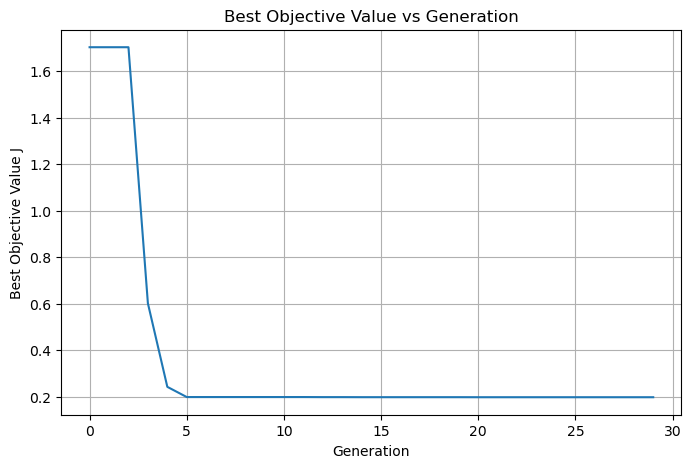

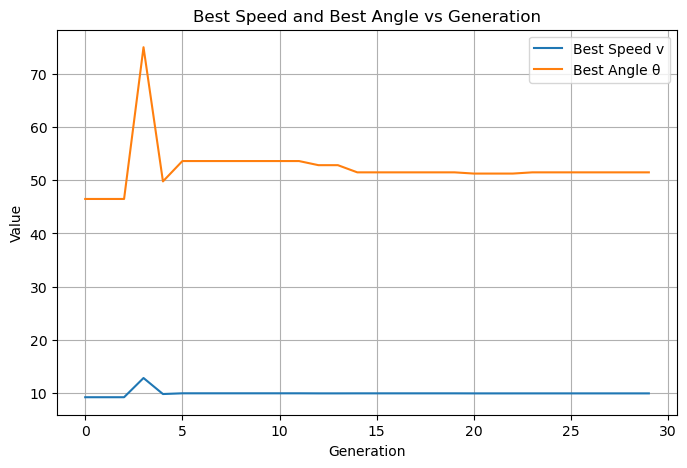

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ROBOT BASKETBALL SHOT OPTIMIZER USING DE/rand/1/bin

# Problem Data
h0 = 1.2
D = 8
H = 3.05
xd = 4
Hd = 2.4
g = 9.81

# DE Parameters
population_size = 8
generations = 30
F = 0.5
CR = 0.7

np.random.seed(22)


# Objective Function
def objective(X):

    v = X[0]
    theta_deg = X[1]

    theta = np.radians(theta_deg)

    yD = h0 + D*np.tan(theta) - (g*D**2)/(2*v**2*np.cos(theta)**2)

    yd = h0 + xd*np.tan(theta) - (g*xd**2)/(2*v**2*np.cos(theta)**2)

    J1 = (yD - H)**2
    J2 = 0.002 * v**2
    J3 = 20 * max(0, Hd - yd)**2

    return J1 + J2 + J3


# Bounds

lower_bounds = np.array([5, 25])
upper_bounds = np.array([15, 75])


# Initial Population

population = np.random.uniform(
    lower_bounds,
    upper_bounds,
    (population_size, 2)
)

fitness = np.array([objective(ind) for ind in population])


# History Storage

best_J_history = []
best_v_history = []
best_theta_history = []


# Differential Evolution

for gen in range(generations):

    new_population = population.copy()

    for i in range(population_size):

        indices = list(range(population_size))
        indices.remove(i)

        r1, r2, r3 = np.random.choice(indices, 3, replace=False)

        # Mutation (DE/rand/1)
        mutant = population[r1] + F * (population[r2] - population[r3])

        mutant = np.clip(mutant, lower_bounds, upper_bounds)

        # Binomial Crossover
        trial = population[i].copy()

        jrand = np.random.randint(2)

        for j in range(2):

            if np.random.rand() <= CR or j == jrand:
                trial[j] = mutant[j]

        # Selection
        trial_fitness = objective(trial)

        if trial_fitness < fitness[i]:
            new_population[i] = trial
            fitness[i] = trial_fitness

    population = new_population

    best_index = np.argmin(fitness)

    best_J_history.append(fitness[best_index])
    best_v_history.append(population[best_index][0])
    best_theta_history.append(population[best_index][1])


# Best Solution

best_index = np.argmin(fitness)

best_v = population[best_index][0]
best_theta = population[best_index][1]

theta = np.radians(best_theta)

yD = h0 + D*np.tan(theta) - (g*D**2)/(2*best_v**2*np.cos(theta)**2)

yd = h0 + xd*np.tan(theta) - (g*xd**2)/(2*best_v**2*np.cos(theta)**2)

best_J = fitness[best_index]


# Output

print("DE RESULTS — Robot Basketball Shot Optimizer")


print(f"Selected Population Size      : {population_size}")
print(f"Selected Generations          : {generations}")

print()

print(f"Best Speed v                  : {best_v:.6f}")
print(f"Best Angle θ                  : {best_theta:.6f}")

print()

print(f"Ball Height at Hoop y(D)      : {yD:.6f}")
print(f"Ball Height at Defender y(xd) : {yd:.6f}")

print()

print(f"Final Objective Value J       : {best_J:.6f}")


# Plot 1

plt.figure(figsize=(8,5))
plt.plot(best_J_history)
plt.title("Best Objective Value vs Generation")
plt.xlabel("Generation")
plt.ylabel("Best Objective Value J")
plt.grid(True)
plt.show()


# Plot 2

plt.figure(figsize=(8,5))
plt.plot(best_v_history, label="Best Speed v")
plt.plot(best_theta_history, label="Best Angle θ")

plt.title("Best Speed and Best Angle vs Generation")
plt.xlabel("Generation")
plt.ylabel("Value")

plt.legend()
plt.grid(True)
plt.show()